# Cumulative PnL

## Getting trades

In [2]:
import pandas as pd

dtype_spec = {
    'action': 'str',
    'orderId': 'int64',
    'orderProduct': 'str',
    'orderSide': 'str',
    'tradePx': 'float64',
    'tradeAmt': 'float64'
}

orders = pd.read_csv('test_logs.csv', sep=';', dtype = dtype_spec, parse_dates=['currentTime'])
trades = orders[orders['action'] == 'filled']
trades.head()

<ipython-input-2-9b21a52ed876>:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  orders = pd.read_csv('test_logs.csv', sep=';', dtype = dtype_spec, parse_dates=['currentTime'])


,currentTime,action,orderId,orderProduct,orderSide,tradePx,tradeAmt
2,1704114002000000000,filled,1,AA,buy,139200.0,2.0
9,1704114009000000000,filled,3,AA,buy,139400.0,3.0
20,1704114020000000000,filled,6,BB,buy,13500.0,1.0
23,1704114023000000000,filled,7,AA,buy,139100.0,1.0
26,1704114026000000000,filled,8,BB,sell,14500.0,3.0


## Calculating realized PnL for each trade

In [6]:
def calculate_pnl(amt, side, open_px, close_px):
  if side == 'buy':
    return amt * (close_px - open_px)
  else:
    return amt * (open_px - close_px)

def calculate_group_pnl(group):
  position_side = ''
  position_amt = 0
  position_px = 0.0
  trade_pnl = 0.0
  realized_pnl = []
  for _, row in group.iterrows():
    order_side = row['orderSide']
    trade_amt = row['tradeAmt']
    trade_px = row['tradePx']
    if position_amt == 0:
      trade_pnl = 0.0
      position_side = order_side
      position_amt = trade_amt
      position_px = trade_px
    elif position_side == order_side:
      trade_pnl = 0.0
      position_px = (position_amt*position_px + trade_amt*trade_px) / (position_amt + trade_amt)
      position_amt += trade_amt
    elif position_amt >= trade_amt:
      trade_pnl = calculate_pnl(trade_amt, position_side, position_px, trade_px)
      position_amt -= trade_amt
    else:
      trade_pnl = calculate_pnl(position_amt, position_side, position_px, trade_px)
      position_side = order_side
      position_amt = trade_amt - position_amt
      position_px = trade_px
    realized_pnl.append(trade_pnl)
  group['realizedPnL'] = realized_pnl
  return group

trades_pnl = trades.groupby('orderProduct', group_keys=False).apply(calculate_group_pnl)
trades_pnl.head()

<ipython-input-6-7f5467d2ec77>:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trades_pnl = trades.groupby('orderProduct', group_keys=False).apply(calculate_group_pnl)


,currentTime,action,orderId,orderProduct,orderSide,tradePx,tradeAmt,realizedPnL
2,1704114002000000000,filled,1,AA,buy,139200.0,2.0,0.0
9,1704114009000000000,filled,3,AA,buy,139400.0,3.0,0.0
20,1704114020000000000,filled,6,BB,buy,13500.0,1.0,0.0
23,1704114023000000000,filled,7,AA,buy,139100.0,1.0,0.0
26,1704114026000000000,filled,8,BB,sell,14500.0,3.0,1000.0


## Total PnL per Security

In [8]:
total_pnl_per_security = trades_pnl.groupby('orderProduct')['realizedPnL'].sum()
print('Total PnL per security:\n', total_pnl_per_security)

Total PnL per security:
 orderProduct
AA    5500.0
BB    3700.0
CC    -710.0
Name: realizedPnL, dtype: float64


## Total PnL

In [12]:
total_pnl = trades_pnl['realizedPnL'].sum()
print('Total PnL:', total_pnl)

Total PnL: 8489.999999999827


## Cumulative Profit and Loss over trades

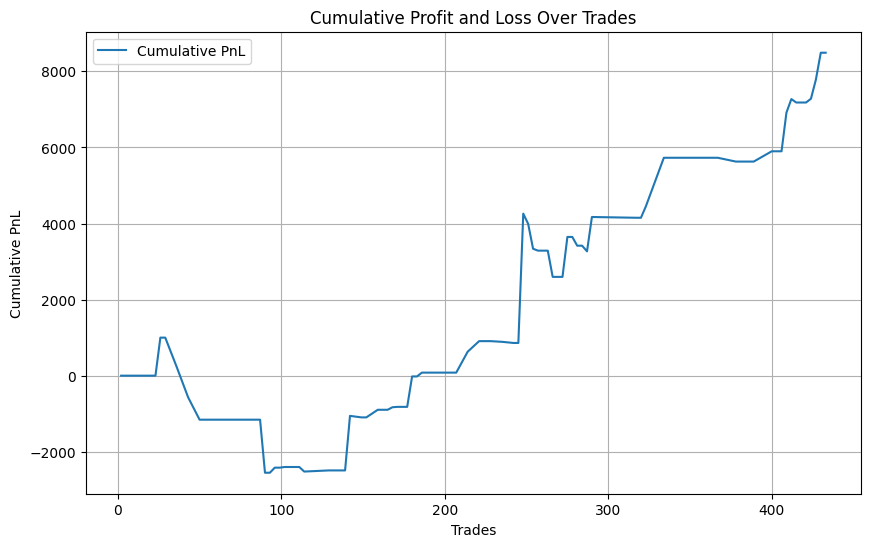

In [13]:
import matplotlib.pyplot as pp

trades_pnl['cumulativePnL'] = trades_pnl['realizedPnL'].cumsum()
pp.figure(figsize=(10, 6))
pp.plot(trades_pnl['cumulativePnL'], label='Cumulative PnL')
pp.title('Cumulative Profit and Loss Over Trades')
pp.xlabel('Trades')
pp.ylabel('Cumulative PnL')
pp.grid(True)
pp.legend()
pp.show()